# Load Data & Overview

In [16]:
import pandas as pd

df = pd.read_csv('train.csv')

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [17]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.883015
yes,0.116985


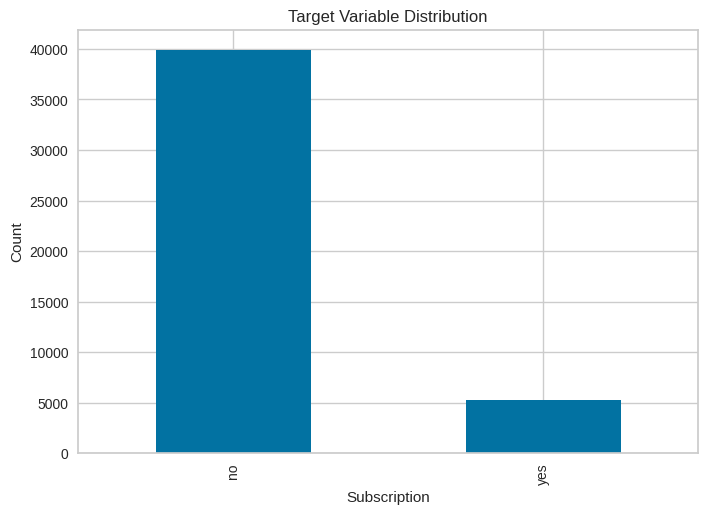

In [18]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.show()

In [19]:
df.select_dtypes(include='number').columns
df.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [20]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


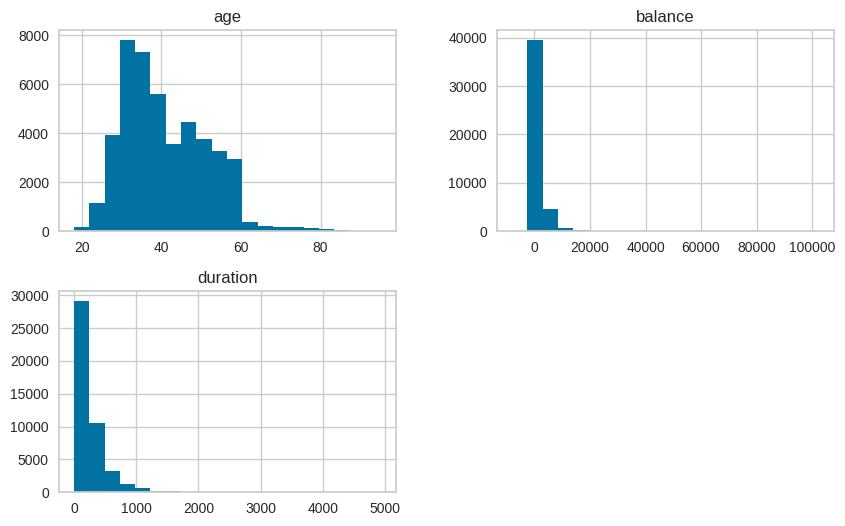

In [21]:
df[['age','balance','duration']].hist(bins=20, figsize=(10,6))
plt.show()


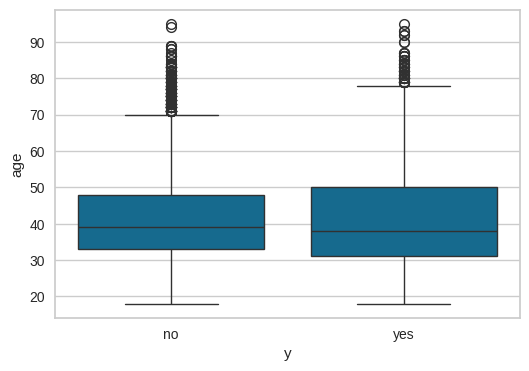

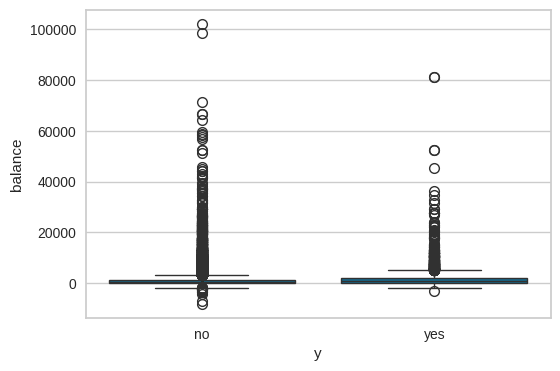

In [22]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='y', y='age', data=df)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='y', y='balance', data=df)
plt.show()

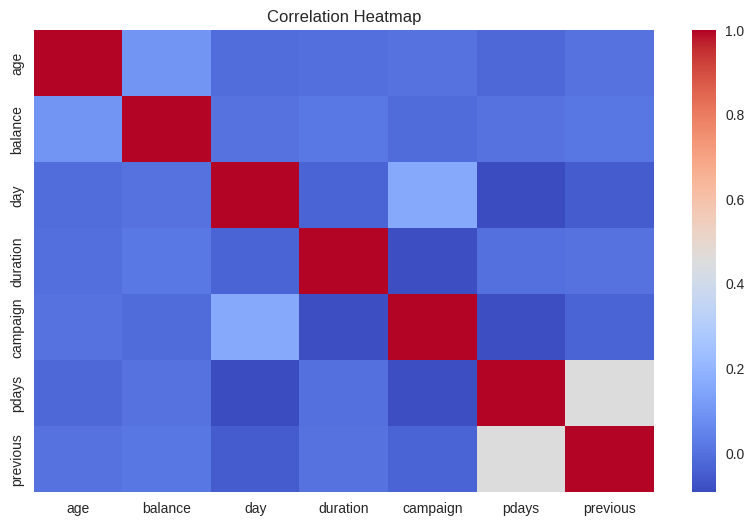

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Data Preprocessing

In [24]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [25]:
df.duplicated().sum()

0

In [26]:
X = df.drop('y', axis=1)
y = df['y']

In [27]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [28]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [29]:
from sklearn.preprocessing import StandardScaler

num_cols = X_encoded.select_dtypes(include='number').columns

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

# STEP 4: Modeling & Performance

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

In [32]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-s1go_34m
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-s1go_34m
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [33]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [34]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df,test_size=0.3,random_state=42,stratify=df['y'])

In [35]:
from pycaret.classification import *

clf = setup(data=train_data,target='y',session_id=42,normalize=True,normalize_method='zscore',
    fold=5,
    verbose=False
)

In [36]:
best_model = compare_models(sort='Recall')
best_model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9082,0.9335,0.9082,0.8994,0.9021,0.4987,0.5059,1.1440
xgboost,Extreme Gradient Boosting,0.9071,0.9281,0.9071,0.8990,0.9017,0.5002,0.5056,1.1760
gbc,Gradient Boosting Classifier,0.9050,0.9249,0.9050,0.8926,0.8945,0.4447,0.4620,3.6080
rf,Random Forest Classifier,0.9034,0.9266,0.9034,0.8895,0.8901,0.4129,0.4382,2.7900
ada,Ada Boost Classifier,0.9015,0.9097,0.9015,0.8884,0.8910,0.4277,0.4433,1.4220
lr,Logistic Regression,0.9004,0.9053,0.9004,0.8854,0.8869,0.3971,0.4204,3.8060
ridge,Ridge Classifier,0.8997,0.9058,0.8997,0.8835,0.8803,0.3448,0.3876,0.7100
lda,Linear Discriminant Analysis,0.8993,0.9058,0.8993,0.8892,0.8927,0.4509,0.4572,0.5800
et,Extra Trees Classifier,0.8974,0.9051,0.8974,0.8803,0.8818,0.3650,0.3917,2.9880
svm,SVM - Linear Kernel,0.8954,0.8530,0.8954,0.8787,0.8810,0.3651,0.3880,0.7120


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [37]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df,test_size=0.3,
                                         random_state=42,
                                         stratify=df['y'])

In [38]:
from pycaret.classification import *
# Setup classification experiment
clf1 = setup(session_id=8717, data=train_data, target='y')
# Compare classification models
models = compare_models(sort='Recall')

,Description,Value
0,Session id,8717
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(31647, 17)"
5,Transformed data shape,"(31647, 49)"
6,Transformed train set shape,"(22152, 49)"
7,Transformed test set shape,"(9495, 49)"
8,Numeric features,7
9,Categorical features,9


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9058,0.9324,0.9058,0.8974,0.9001,0.4909,0.4970,1.4050
gbc,Gradient Boosting Classifier,0.9055,0.9241,0.9055,0.8937,0.8956,0.4521,0.4684,3.7290
xgboost,Extreme Gradient Boosting,0.9033,0.9261,0.9033,0.8958,0.8986,0.4873,0.4915,0.9230
lr,Logistic Regression,0.9003,0.9017,0.9003,0.8850,0.8861,0.3904,0.4159,2.1930
rf,Random Forest Classifier,0.9001,0.9244,0.9001,0.8851,0.8865,0.3945,0.4183,2.8700
ada,Ada Boost Classifier,0.9000,0.9086,0.9000,0.8868,0.8897,0.4220,0.4366,1.3320
ridge,Ridge Classifier,0.8991,0.9068,0.8991,0.8827,0.8796,0.3413,0.3839,0.4200
lda,Linear Discriminant Analysis,0.8991,0.9068,0.8991,0.8882,0.8916,0.4425,0.4506,0.4830
et,Extra Trees Classifier,0.8968,0.9077,0.8968,0.8802,0.8822,0.3698,0.3941,2.9760
dummy,Dummy Classifier,0.8830,0.5000,0.8830,0.7798,0.8282,0.0000,0.0000,0.4980


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

# สร้าง Model

In [39]:
from pycaret.classification import *
lgbm = create_model('lightgbm')
xgb  = create_model('xgboost')
lr   = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9061,0.9354,0.9061,0.8964,0.8992,0.4810,0.4894
1,0.9012,0.9381,0.9012,0.8924,0.8956,0.4708,0.4757
2,0.9016,0.9305,0.9016,0.8919,0.8952,0.4642,0.4704
3,0.8998,0.9195,0.8998,0.8906,0.8940,0.4605,0.4654
4,0.9111,0.9380,0.9111,0.9032,0.9056,0.5185,0.5248
5,0.9088,0.9396,0.9088,0.9007,0.9033,0.5072,0.5131
6,0.9065,0.9291,0.9065,0.8989,0.9016,0.5016,0.5060
7,0.9007,0.9245,0.9007,0.8927,0.8958,0.4732,0.4769
8,0.9169,0.9376,0.9169,0.9087,0.9100,0.5337,0.5456


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9039,0.9332,0.9039,0.8970,0.8997,0.4946,0.4977
1,0.9048,0.9344,0.9048,0.8963,0.8992,0.4882,0.4937
2,0.8998,0.9249,0.8998,0.8901,0.8935,0.4564,0.4621
3,0.8962,0.9135,0.8962,0.8915,0.8936,0.4725,0.4734
4,0.9106,0.9325,0.9106,0.9030,0.9054,0.5188,0.5244
5,0.9056,0.9322,0.9056,0.8999,0.9023,0.5112,0.5133
6,0.9034,0.9236,0.9034,0.8955,0.8984,0.4856,0.4898
7,0.8980,0.9172,0.8980,0.8900,0.8932,0.4608,0.4641
8,0.9129,0.9286,0.9129,0.9049,0.9071,0.5247,0.5320


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8953,0.9075,0.8953,0.8764,0.8774,0.3346,0.3663
1,0.8953,0.9071,0.8953,0.8797,0.8833,0.3860,0.4022
2,0.8980,0.8973,0.8980,0.8807,0.8812,0.3574,0.3886
3,0.8953,0.8738,0.8953,0.8784,0.8817,0.3705,0.3904
4,0.9065,0.9208,0.9065,0.8938,0.8925,0.4228,0.4531
5,0.9011,0.9055,0.9011,0.8870,0.8893,0.4143,0.4331
6,0.9025,0.9039,0.9025,0.8879,0.8883,0.4015,0.4285
7,0.8944,0.8913,0.8944,0.8764,0.8794,0.3544,0.3771
8,0.9070,0.9116,0.9070,0.8944,0.8935,0.4292,0.4580


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [40]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

def eval_pycaret_on_test(model, model_name, test_data, target_col='y', positive_label='yes'):
    # Predict on test set
    pred_df = predict_model(model, data=test_data)

    y_true = test_data[target_col]
    y_pred = pred_df['prediction_label']

    # Metrics (positive class = 'yes')
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=positive_label)
    rec  = recall_score(y_true, y_pred, pos_label=positive_label)
    f1   = f1_score(y_true, y_pred, pos_label=positive_label)

    # Confusion Matrix (จัดเรียง label ให้ชัด)
    labels = ['no', 'yes']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual_{l}" for l in labels],
        columns=[f"Pred_{l}" for l in labels]
    )

    print(f"\n==================== {model_name} ====================")
    print("Accuracy :", round(acc, 4))
    print("Precision(yes):", round(prec, 4))
    print("Recall(yes)   :", round(rec, 4))
    print("F1(yes)       :", round(f1, 4))

    print("\nConfusion Matrix:")
    display(cm_df)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision_yes": prec,
        "Recall_yes": rec,
        "F1_yes": f1
    }

# Run Model with Train Set

In [41]:
results = []
results.append(eval_pycaret_on_test(lgbm, "LightGBM", train_data))
results.append(eval_pycaret_on_test(xgb,  "XGBoost",  train_data))
results.append(eval_pycaret_on_test(lr,   "Logistic Regression", train_data))

summary = pd.DataFrame(results).sort_values("Recall_yes", ascending=False)
summary

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9320,0.9633,0.9320,0.9276,0.9287,0.6396,0.6446



==================== LightGBM ====================
Accuracy : 0.932
Precision(yes): 0.7621
Recall(yes)   : 0.6091
F1(yes)       : 0.6771

Confusion Matrix:


,Pred_no,Pred_yes
Actual_no,27241,704
Actual_yes,1447,2255



Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.97      0.96     27945
         yes       0.76      0.61      0.68      3702

    accuracy                           0.93     31647
   macro avg       0.86      0.79      0.82     31647
weighted avg       0.93      0.93      0.93     31647



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9480,0.9740,0.9480,0.9455,0.9459,0.7283,0.7322


...

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9009,0.9054,0.9009,0.8857,0.8869,0.3954,0.4204



==================== Logistic Regression ====================
Accuracy : 0.9009
Precision(yes): 0.6455
Recall(yes)   : 0.3385
F1(yes)       : 0.4441

Confusion Matrix:


,Pred_no,Pred_yes
Actual_no,27257,688
Actual_yes,2449,1253



Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     27945
         yes       0.65      0.34      0.44      3702

    accuracy                           0.90     31647
   macro avg       0.78      0.66      0.69     31647
weighted avg       0.89      0.90      0.89     31647



,Model,Accuracy,Precision_yes,Recall_yes,F1_yes
1,XGBoost,0.947957,0.833496,0.693679,0.757187
0,LightGBM,0.932031,0.762082,0.609130,0.677076
2,Logistic Regression,0.900875,0.645544,0.338466,0.444090


# Run Model with Test Set

In [42]:
results = []
results.append(eval_pycaret_on_test(lgbm, "LightGBM", test_data))
results.append(eval_pycaret_on_test(xgb,  "XGBoost",  test_data))
results.append(eval_pycaret_on_test(lr,   "Logistic Regression", test_data))

summary = pd.DataFrame(results).sort_values("Recall_yes", ascending=False)
summary

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9092,0.9333,0.9092,0.9011,0.9037,0.5088,0.5150



==================== LightGBM ====================
Accuracy : 0.9092
Precision(yes): 0.6483
Recall(yes)   : 0.4902
F1(yes)       : 0.5583

Confusion Matrix:


,Pred_no,Pred_yes
Actual_no,11555,422
Actual_yes,809,778



Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.96      0.95     11977
         yes       0.65      0.49      0.56      1587

    accuracy                           0.91     13564
   macro avg       0.79      0.73      0.75     13564
weighted avg       0.90      0.91      0.90     13564



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9047,0.9258,0.9047,0.8966,0.8995,0.4896,0.4945


...

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9008,0.9026,0.9008,0.8856,0.8867,0.3936,0.4192



==================== Logistic Regression ====================
Accuracy : 0.9008
Precision(yes): 0.6468
Recall(yes)   : 0.3359
F1(yes)       : 0.4421

Confusion Matrix:


,Pred_no,Pred_yes
Actual_no,11686,291
Actual_yes,1054,533



Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     11977
         yes       0.65      0.34      0.44      1587

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.69     13564
weighted avg       0.89      0.90      0.89     13564



,Model,Accuracy,Precision_yes,Recall_yes,F1_yes
0,LightGBM,0.909245,0.648333,0.490233,0.558306
1,XGBoost,0.904748,0.619627,0.481411,0.541844
2,Logistic Regression,0.900840,0.646845,0.335854,0.442140


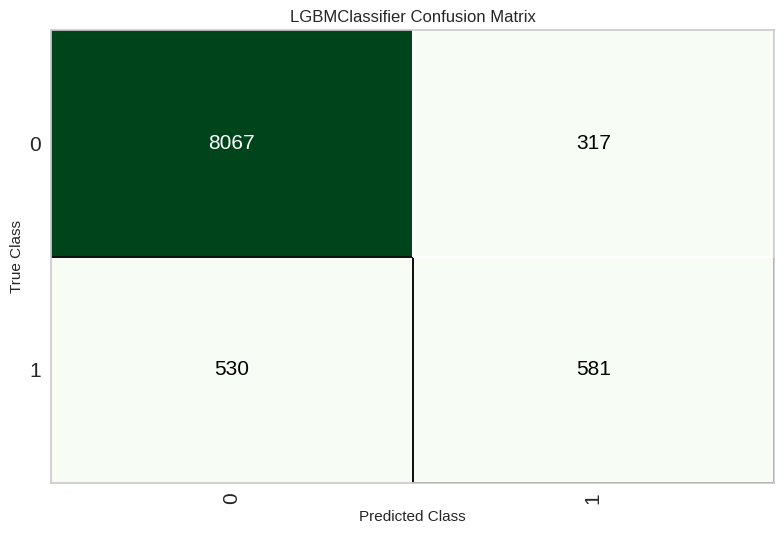

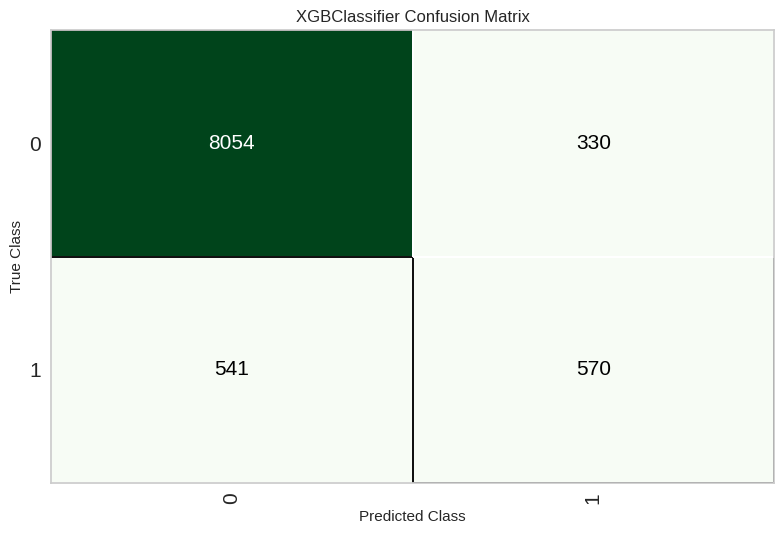

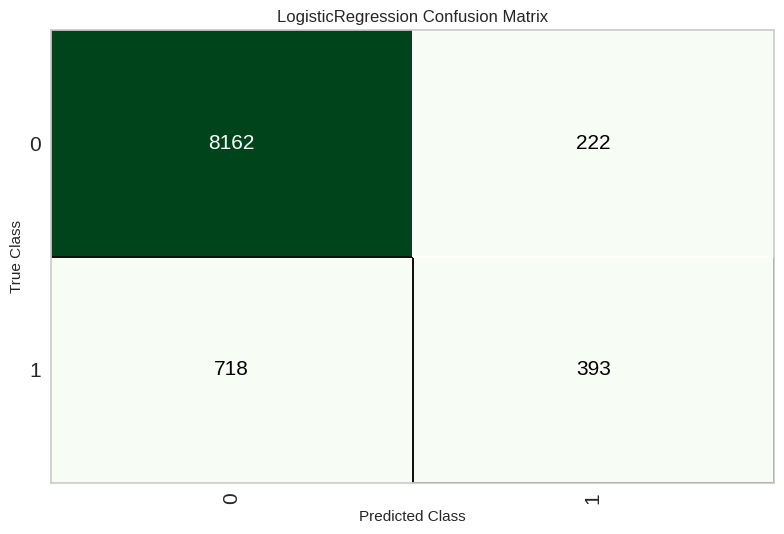

In [43]:
plot_model(lgbm, plot='confusion_matrix')
plot_model(xgb,  plot='confusion_matrix')
plot_model(lr,   plot='confusion_matrix')

# Save Best Model

In [44]:
best_model = lgbm

In [45]:
save_model(best_model, 'Bank_Term_Deposit_LightGBM_Final')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'balance', 'day',
                                              'duration', 'campaign', 'pdays',
                                              'previous'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',
        